<div style="padding: 24px 0; border-bottom: 2px solid currentColor;">
<p style="opacity: 0.6; margin: 0 0 12px; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Sigmoidal &nbsp;&middot;&nbsp; STAR Research Institute</p>
<h1 style="margin: 0; font-size: 30px; font-weight: 600;">Introdução ao Python</h1>
<h3 style="margin: 8px 0 0; font-size: 18px; font-weight: 400; opacity: 0.85;">Aula 4 — Complexidade e algoritmos práticos</h3>
<p style="opacity: 0.6; margin: 16px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
<p style="margin: 16px 0 0;"><a href="https://colab.research.google.com/github/carlosfab/introducao-python/blob/main/notebooks/aula4_complexidade.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir no Google Colab"/></a></p>
</div>

Chegamos à última aula do nivelamento. Nas três primeiras, construímos a linguagem: tipos, controle de fluxo, funções, estruturas de dados e classes. Hoje a pergunta muda. Não se trata mais de saber se o programa funciona, mas de saber **quanto ele custa**: quanto tempo um algoritmo leva para resolver um problema e o que fazer quando a resposta exata é cara demais.

O percurso de hoje:

1. **Complexidade algorítmica**: a notação $O$ grande e as classes de crescimento
2. **O problema da Mochila**: algoritmo guloso versus força bruta
3. **Monte Carlo**: estimando $\pi$ com pontos aleatórios
4. **Imagem como array**: a ponte para a Visão Computacional

Antes de qualquer código, o setup padrão das aulas anteriores. Os módulos `time` e `random`, da biblioteca padrão, serão usados ao longo de toda a aula.

In [1]:
import time
import random

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

print('Setup pronto.')

Setup pronto.


## Quanto custa executar um programa?

Na Aula 1, comparamos duas estratégias para aproximar a raiz quadrada: a enumeração exaustiva precisou de um milhão de passos para o que a bisseção resolveu em vinte. Prometemos voltar ao assunto com mais rigor, e o momento é agora.

A pergunta que abre o capítulo 11 do Guttag é direta: quanto tempo uma função demora para rodar? A resposta ingênua seria cronometrar. O problema é que o resultado depende da velocidade do computador, da implementação do Python e do valor da entrada. Precisamos de uma medida mais estável.

Para começar a investigação, considere a **busca linear**: percorrer uma lista do início ao fim procurando um valor.

In [2]:
def busca_linear(L, x):
    for e in L:
        if e == x:
            return True
    return False

In [3]:
L = list(range(10_000_000))

Vamos cronometrar dois cenários extremos sobre essa lista de dez milhões de elementos: procurar o primeiro elemento e procurar um valor que não existe.

In [4]:
inicio = time.perf_counter()
busca_linear(L, 0)
print(time.perf_counter() - inicio, 'segundos')

7.421203190460801e-05 segundos


In [5]:
inicio = time.perf_counter()
busca_linear(L, -1)
print(time.perf_counter() - inicio, 'segundos')

0.16742516495287418 segundos


A mesma função, na mesma máquina, com a mesma lista: microssegundos em um caso, décimos de segundo no outro. A diferença está apenas em **quanto trabalho** a entrada exige. Por isso, distinguimos três cenários:

- **Melhor caso**: o mínimo de trabalho possível (o valor está na primeira posição).
- **Pior caso**: o máximo (o valor não está na lista e percorremos tudo).
- **Caso médio**: a média sobre todas as entradas possíveis.

Em engenharia, o foco está no **pior caso**: ele fornece uma garantia, um teto que nenhuma entrada ultrapassa.

Para eliminar a dependência da máquina, medimos o custo em **passos**: operações elementares como uma atribuição, uma comparação ou uma operação aritmética, todas de tempo aproximadamente constante. Considere o fatorial iterativo.

In [6]:
def fatorial(n):
    resposta = 1
    while n > 1:
        resposta *= n
        n -= 1
    return resposta

fatorial(5)

120

A contagem dá 1 passo para a atribuição inicial, cerca de 5 passos por volta do laço (o teste e as duas atribuições) e 1 para o `return`: aproximadamente $5n + 2$ passos para a entrada $n$.

Para $n = 1000$, são 5002 passos. E aqui está a observação central do capítulo: quando $n$ cresce, a diferença entre $5n + 2$ e $5n$ é irrelevante, e até o fator 5 importa pouco frente à diferença entre, por exemplo, $5n$ e $5n^2$. O que interessa é como o custo **cresce** com o tamanho da entrada. Essa é a **ordem de crescimento** do algoritmo.

## A notação O grande

A **notação assintótica** descreve como o tempo de execução cresce quando a entrada tende ao infinito, ignorando constantes aditivas e multiplicativas. Escrevemos $O(\cdot)$ para indicar esse limite superior sobre o pior caso.

As classes mais importantes, da mais rápida para a mais lenta:

| Notação | Nome | Exemplo típico |
|---|---|---|
| $O(1)$ | constante | `len(L)`, acessar `L[i]` |
| $O(\log n)$ | logarítmica | busca por bisseção |
| $O(n)$ | linear | busca linear |
| $O(n \log n)$ | log-linear | ordenação eficiente (`sorted`) |
| $O(n^2)$ | quadrática | laços aninhados |
| $O(2^n)$ | exponencial | enumerar todos os subconjuntos |

Vamos examinar exemplos concretos de cada classe.

### Crescimento logarítmico

A função abaixo converte um inteiro para a sua representação decimal em string. Quantas iterações o laço executa? A cada volta, `i` é dividido por 10. O número de voltas é, portanto, o número de dígitos de `i`, aproximadamente $\log_{10}(i)$.

In [7]:
def int_para_str(i):
    digitos = '0123456789'
    if i == 0:
        return '0'
    resultado = ''
    while i > 0:
        resultado = digitos[i % 10] + resultado
        i = i // 10
    return resultado

In [8]:
int_para_str(123456)

'123456'

Reduzir o problema por um fator constante a cada passo é a assinatura do crescimento logarítmico, o mesmo comportamento da bisseção da Aula 1. Dobrar a entrada acrescenta apenas um passo.

### Crescimento linear

A função abaixo soma os dígitos de uma string numérica. Cada caractere é visitado exatamente uma vez: o custo é proporcional ao comprimento da entrada, $O(n)$.

In [9]:
def soma_digitos(s):
    total = 0
    for c in s:
        total += int(c)
    return total

soma_digitos('123456')

21

### Crescimento quadrático

Para verificar se `L1` é subconjunto de `L2`, comparamos cada elemento de `L1` com os elementos de `L2`. No pior caso, o laço interno percorre `L2` inteira para cada elemento de `L1`: custo $O(n_1 \cdot n_2)$, ou simplesmente $O(n^2)$ para listas de tamanho comparável. Laços aninhados são a origem mais comum de algoritmos quadráticos.

In [10]:
def eh_subconjunto(L1, L2):
    for e1 in L1:
        achou = False
        for e2 in L2:
            if e1 == e2:
                achou = True
                break
        if not achou:
            return False
    return True

In [11]:
eh_subconjunto([3, 1], [0, 1, 2, 3])

True

In [12]:
eh_subconjunto([3, 5], [0, 1, 2, 3])

False

### Crescimento exponencial

Quantos subconjuntos tem um conjunto de $n$ elementos? Cada elemento pode estar presente ou ausente: duas escolhas independentes por elemento, logo $2^n$ combinações. O Guttag gera essas combinações associando cada subconjunto a um número binário de $n$ bits; a implementação abaixo segue o mesmo raciocínio de forma incremental. A cada novo item, todos os subconjuntos existentes são duplicados: uma cópia sem o item e uma com ele.

In [13]:
def subconjuntos(L):
    resultado = [[]]
    for item in L:
        novos = [s + [item] for s in resultado]
        resultado = resultado + novos
    return resultado

In [14]:
subconjuntos(['x', 'y', 'z'])

[[], ['x'], ['y'], ['x', 'y'], ['z'], ['x', 'z'], ['y', 'z'], ['x', 'y', 'z']]

Oito subconjuntos para três elementos, incluindo o vazio e o conjunto completo. O problema é a velocidade com que esse número explode.

In [15]:
len(subconjuntos(list('abcdefghij')))

1024

Com 10 itens, 1024 subconjuntos. Com 20, mais de um milhão. Com 26, sessenta e sete milhões. Algoritmos exponenciais são impraticáveis para qualquer entrada que não seja muito pequena, e nenhum hardware resolve isso: dobrar a velocidade do computador permite processar **um** item a mais.

### As curvas lado a lado

Vamos visualizar as classes de crescimento em um mesmo gráfico.

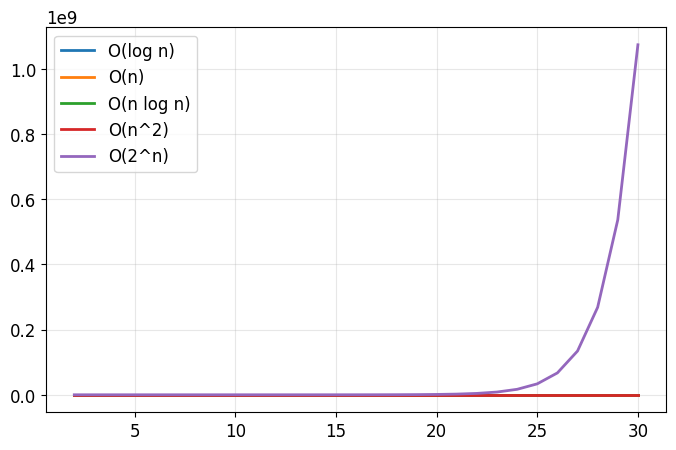

In [16]:
n = np.arange(2, 31)

plt.plot(n, np.log2(n), label='O(log n)')
plt.plot(n, n, label='O(n)')
plt.plot(n, n * np.log2(n), label='O(n log n)')
plt.plot(n, n**2, label='O(n^2)')
plt.plot(n, 2.0**n, label='O(2^n)')
plt.legend()
plt.show()

Na escala linear, a curva exponencial esmaga todas as outras: até a quadrática parece colada no zero. Para enxergar a hierarquia completa, usamos escala logarítmica no eixo $y$.

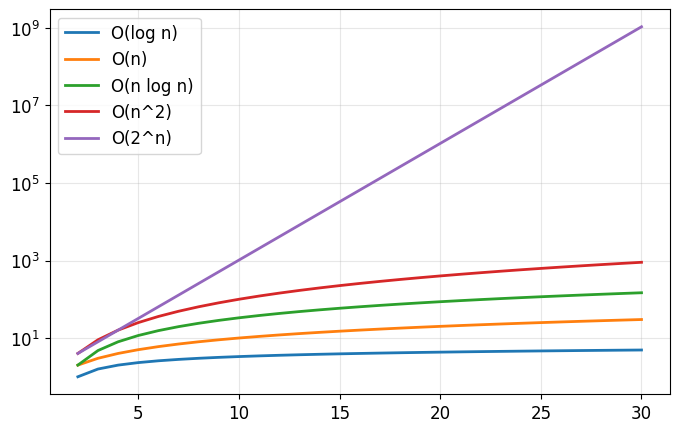

In [17]:
plt.plot(n, np.log2(n), label='O(log n)')
plt.plot(n, n, label='O(n)')
plt.plot(n, n * np.log2(n), label='O(n log n)')
plt.plot(n, n**2, label='O(n^2)')
plt.plot(n, 2.0**n, label='O(2^n)')
plt.yscale('log')
plt.legend()
plt.show()

Em escala logarítmica, a exponencial vira uma reta e as demais classes se separam com clareza. A distância vertical entre as curvas é o que diferencia um programa que responde em milissegundos de um que não termina.

A teoria prevê que a busca linear é $O(n)$. Vamos confirmar no cronômetro: dobrando o tamanho da lista, o tempo de pior caso deve dobrar.

In [18]:
tamanhos = [1_000_000, 2_000_000, 4_000_000, 8_000_000]
tempos = []

for tam in tamanhos:
    lista = list(range(tam))
    inicio = time.perf_counter()
    busca_linear(lista, -1)
    tempos.append(time.perf_counter() - inicio)

tempos

[0.016346819989848882,
 0.03428493201499805,
 0.06653752096462995,
 0.13690373301506042]

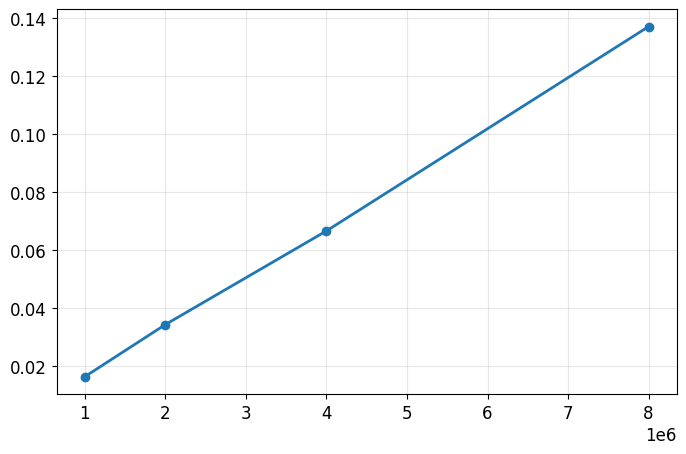

In [19]:
plt.plot(tamanhos, tempos, marker='o')
plt.show()

Uma reta: cada dobra de tamanho dobra o tempo. A medição empírica confirma a análise teórica, e essa é exatamente a relação entre as duas. A análise diz **como** o custo cresce; a medição diz quanto custa nesta máquina.

## O problema da Mochila

Com a linguagem da complexidade em mãos, podemos enfrentar uma classe central de problemas em computação: os **problemas de otimização**, nos quais procuramos a melhor solução dentro de um conjunto de possibilidades, sujeito a restrições.

O exemplo clássico do capítulo 14 do Guttag: um ladrão invade uma casa com uma mochila que suporta no máximo 20 kg. Há mais objetos de valor do que ele consegue carregar. Quais levar, para maximizar o valor total sem ultrapassar o limite de peso?

| Item | Valor | Peso (kg) |
|---|---|---|
| relógio | 175 | 10 |
| quadro | 90 | 9 |
| rádio | 20 | 4 |
| vaso | 50 | 2 |
| livro | 10 | 1 |
| computador | 200 | 20 |

Para representar os objetos, definimos uma classe, como aprendemos na Aula 3. O método especial `__repr__` controla como cada item é exibido.

In [20]:
class Item:
    def __init__(self, nome, valor, peso):
        self.nome = nome
        self.valor = valor
        self.peso = peso

    def __repr__(self):
        return f'<{self.nome}, valor={self.valor}, peso={self.peso}>'

In [21]:
itens = [
    Item('relógio', 175, 10),
    Item('quadro', 90, 9),
    Item('rádio', 20, 4),
    Item('vaso', 50, 2),
    Item('livro', 10, 1),
    Item('computador', 200, 20),
]

### O algoritmo guloso

A estratégia mais natural: escolher primeiro o melhor item, depois o segundo melhor, e assim por diante, enquanto houver espaço na mochila. Esse é um **algoritmo guloso** (*greedy*): em cada passo, ele faz a escolha localmente ótima e nunca volta atrás.

Resta definir o que significa "melhor". O item mais valioso? O mais leve? O de maior valor por quilo? A função abaixo recebe o critério como parâmetro, aproveitando o fato de funções serem objetos em Python, como vimos na Aula 2.

In [22]:
def guloso(itens, capacidade, criterio):
    ordenados = sorted(itens, key=criterio, reverse=True)
    mochila = []
    valor_total, peso_total = 0, 0
    for item in ordenados:
        if peso_total + item.peso <= capacidade:
            mochila.append(item)
            peso_total += item.peso
            valor_total += item.valor
    return mochila, valor_total

Três critérios, três respostas. Primeiro, guloso pelo valor:

In [23]:
guloso(itens, 20, lambda item: item.valor)

([<computador, valor=200, peso=20>], 200)

O computador ocupa a mochila inteira: valor total 200. Agora pelo peso. Como queremos os mais leves primeiro e a ordenação é decrescente, o critério é o inverso do peso.

In [24]:
guloso(itens, 20, lambda item: 1 / item.peso)

([<livro, valor=10, peso=1>,
  <vaso, valor=50, peso=2>,
  <rádio, valor=20, peso=4>,
  <quadro, valor=90, peso=9>],
 170)

Quatro itens leves, valor total 170: pior que a primeira tentativa. Por fim, pela densidade de valor (valor por quilo):

In [25]:
guloso(itens, 20, lambda item: item.valor / item.peso)

([<vaso, valor=50, peso=2>,
  <relógio, valor=175, peso=10>,
  <livro, valor=10, peso=1>,
  <rádio, valor=20, peso=4>],
 255)

O melhor resultado até aqui: 255. Mas será o melhor possível? O guloso nunca reconsidera uma escolha, e uma sequência de decisões localmente ótimas não garante o **ótimo global**.

### Força bruta

Para garantir o ótimo, o caminho é examinar **todas** as combinações de itens, descartar as que excedem o peso e ficar com a de maior valor. As combinações de itens são exatamente os subconjuntos que geramos na seção anterior.

In [26]:
def forca_bruta(itens, capacidade):
    melhor_mochila, melhor_valor = [], 0
    for candidato in subconjuntos(itens):
        valor = sum(item.valor for item in candidato)
        peso = sum(item.peso for item in candidato)
        if peso <= capacidade and valor > melhor_valor:
            melhor_mochila = candidato
            melhor_valor = valor
    return melhor_mochila, melhor_valor

In [27]:
forca_bruta(itens, 20)

([<relógio, valor=175, peso=10>,
  <quadro, valor=90, peso=9>,
  <livro, valor=10, peso=1>],
 275)

Valor 275, com uma combinação que nenhum dos três gulosos encontrou. O guloso por densidade começa pelo vaso e pelo relógio e, com isso, deixa de lado a dupla quadro e livro.

O preço da exatidão está na complexidade: são $2^n$ subconjuntos e, para cada um, somamos valores e pesos. Custo total: $O(n \cdot 2^n)$. Vamos sentir esse crescimento no cronômetro, com conjuntos de itens aleatórios cada vez maiores.

In [28]:
quantidades = [10, 12, 14, 16, 18, 20]
tempos = []

for n in quantidades:
    aleatorios = [Item(str(i), random.randint(1, 100), random.randint(1, 10))
                  for i in range(n)]
    inicio = time.perf_counter()
    forca_bruta(aleatorios, 20)
    tempos.append(time.perf_counter() - inicio)

tempos

[0.0013268670300021768,
 0.004674807016272098,
 0.023337271995842457,
 0.2584805079968646,
 0.9422501259832643,
 3.231016952020582]

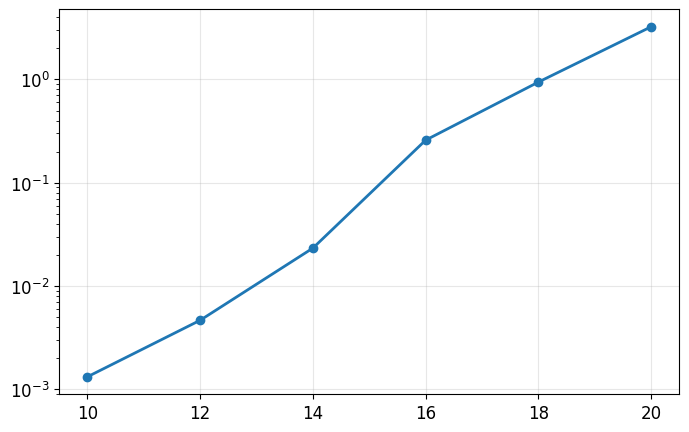

In [29]:
plt.plot(quantidades, tempos, marker='o')
plt.yscale('log')
plt.show()

Na escala logarítmica, uma reta: a cada dois itens, o tempo quadruplica. Com 30 itens seriam minutos; com 50, décadas. O problema da Mochila 0/1 é **inerentemente exponencial**: não existe algoritmo conhecido que garanta o ótimo em tempo polinomial.

É por isso que algoritmos gulosos seguem amplamente usados na prática. Custam $O(n \log n)$ (o custo da ordenação) e entregam uma aproximação frequentemente boa, ainda que sem garantia. A escolha entre o ótimo caro e a aproximação barata é um dos dilemas permanentes da computação.

## Monte Carlo: estimando π

Mudamos agora de estratégia: se enumerar todas as possibilidades é caro demais, podemos **sortear** algumas. Métodos de **Monte Carlo** usam aleatoriedade para estimar quantidades que não têm nada de aleatório. O exemplo do capítulo 18 do Guttag é estimar $\pi$, uma ideia que remonta a Buffon e Laplace, no século XVIII.

Inscreva um círculo de raio 1 em um quadrado de lado 2. A área do círculo é $\pi r^2 = \pi$; a do quadrado, 4. Se sorteamos pontos uniformemente dentro do quadrado, a fração que cai dentro do círculo aproxima a razão entre as áreas:

$$\frac{\text{pontos no círculo}}{\text{pontos no quadrado}} \approx \frac{\pi}{4}$$

Por simetria, basta trabalhar com o primeiro quadrante: sorteamos $x$ e $y$ entre 0 e 1 e verificamos se o ponto está a distância no máximo 1 da origem, isto é, se $x^2 + y^2 \le 1$.

In [30]:
def estimar_pi(num_pontos):
    dentro = 0
    for _ in range(num_pontos):
        x = random.random()
        y = random.random()
        if x**2 + y**2 <= 1:
            dentro += 1
    return 4 * dentro / num_pontos

In [31]:
estimar_pi(1_000)

3.18

In [32]:
estimar_pi(1_000_000)

3.142596

Com mil pontos, o erro aparece já na segunda casa decimal; com um milhão, a estimativa se estabiliza em torno do valor verdadeiro. Antes de estudar essa convergência, vale **ver** a simulação. Com NumPy, sorteamos todos os pontos de uma vez, sem laço, e usamos um array booleano para separar quem caiu dentro do círculo.

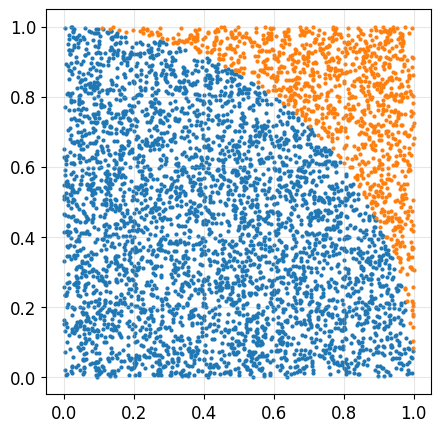

In [33]:
xs = np.random.random(5000)
ys = np.random.random(5000)
dentro = xs**2 + ys**2 <= 1

plt.scatter(xs[dentro], ys[dentro], s=4)
plt.scatter(xs[~dentro], ys[~dentro], s=4)
plt.gca().set_aspect('equal')
plt.show()

O quarto de círculo aparece sozinho, desenhado pelo acaso. A estimativa de $\pi$ é 4 vezes a fração de pontos dentro, que é exatamente a média do array booleano (`True` vale 1, `False` vale 0):

In [34]:
4 * dentro.mean()

np.float64(3.14)

### A convergência

Quantos pontos são necessários para uma boa estimativa? Vamos acompanhar o resultado enquanto o número de pontos cresce em potências de 10.

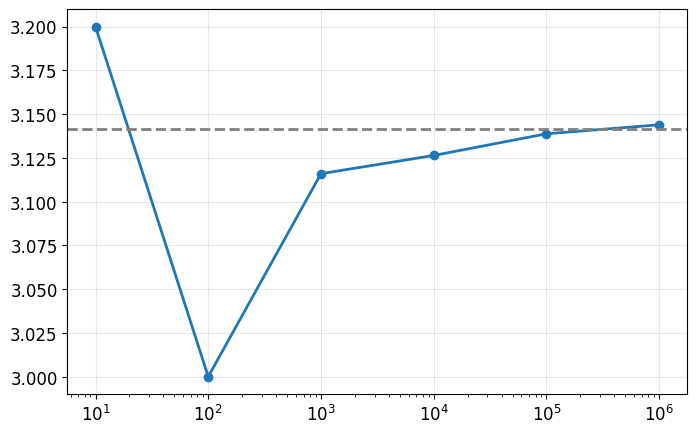

In [35]:
quantidades = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
estimativas = [estimar_pi(q) for q in quantidades]

plt.plot(quantidades, estimativas, marker='o')
plt.axhline(np.pi, linestyle='--', color='gray')
plt.xscale('log')
plt.show()

A estimativa converge para a linha tracejada, mas observe o custo: cada casa decimal adicional de precisão exige cerca de cem vezes mais pontos.

O Guttag encerra o capítulo com um alerta importante: uma conclusão **estatisticamente válida** não é o mesmo que uma conclusão **correta**. Se houver um erro conceitual na simulação (no exemplo do livro, trocar o fator 4 por 2), ela convergirá com toda a estabilidade do mundo para a resposta errada. Antes de confiar em uma simulação, é preciso validar o modelo contra a realidade.

## Imagem como array: a ponte para a Visão Computacional

Para encerrar o curso, uma amostra do que vem pela frente na pós-graduação. Toda imagem digital é, por trás da interface, uma **matriz de números**. Em tons de cinza, cada pixel é um inteiro de 0 (preto) a 255 (branco); em cores, cada pixel carrega três valores: vermelho, verde e azul. Tudo o que fizemos no curso (indexação, slicing, comparações, funções sobre arrays) se aplica diretamente.

Vamos trabalhar com uma astrofotografia da Via Láctea. O arquivo está no repositório do curso; a célula abaixo usa a cópia local, se existir, ou baixa o arquivo (caso do Colab).

In [36]:
import os
import urllib.request
from PIL import Image

caminho = '../data/astrofoto.jpg'
if not os.path.exists(caminho):
    url = 'https://raw.githubusercontent.com/carlosfab/introducao-python/main/data/astrofoto.jpg'
    caminho, _ = urllib.request.urlretrieve(url, 'astrofoto.jpg')

img = Image.open(caminho)
img.size

(1280, 720)

A biblioteca Pillow carrega o arquivo; a conversão para array NumPy revela a estrutura por baixo.

In [37]:
a = np.array(img)
a.shape

(720, 1280, 3)

Três dimensões: 720 linhas, 1280 colunas e 3 canais de cor. Cada posição da matriz é um pixel.

In [38]:
a[300, 500]

array([104, 108, 119], dtype=uint8)

Esses são os três valores do pixel na linha 300, coluna 500: as intensidades de vermelho, verde e azul, cada uma entre 0 e 255. Para exibir a matriz como imagem, `plt.imshow`.

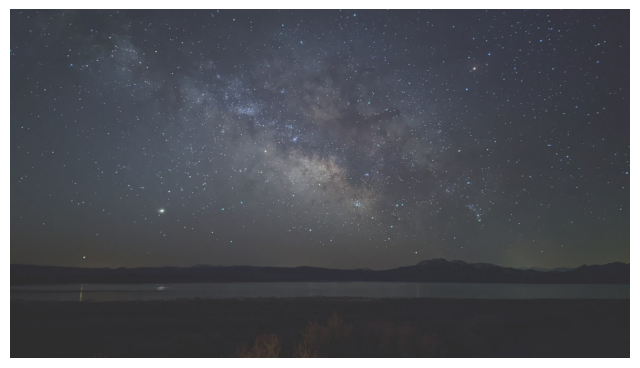

In [39]:
plt.imshow(a)
plt.axis('off')
plt.show()

Em Visão Computacional, a cor é muitas vezes dispensável. A conversão para tons de cinza reduz a matriz a duas dimensões: uma única intensidade por pixel.

In [40]:
cinza = np.array(img.convert('L'))
cinza.shape

(720, 1280)

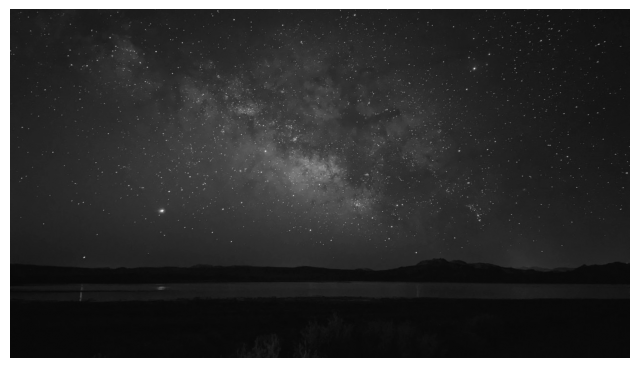

In [41]:
plt.imshow(cinza, cmap='gray')
plt.axis('off')
plt.show()

O slicing da Aula 2 funciona aqui sem nenhuma novidade: recortar uma imagem é fatiar uma matriz. Vamos isolar o céu, as primeiras 400 linhas.

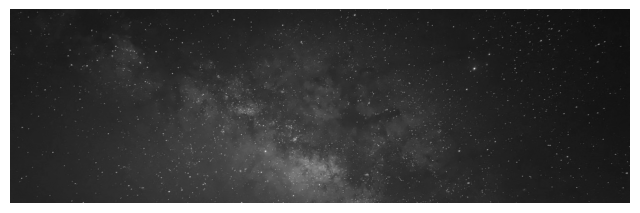

In [42]:
ceu = cinza[:400, :]

plt.imshow(ceu, cmap='gray')
plt.axis('off')
plt.show()

Para destacar as estrelas, usamos uma comparação booleana, a mesma operação que separou os pontos dentro e fora do círculo no Monte Carlo. Pixels acima de um limiar de intensidade viram `True`; o resto, `False`. Em Visão Computacional, isso se chama **limiarização** (*thresholding*) e é a forma mais simples de segmentação de imagens.

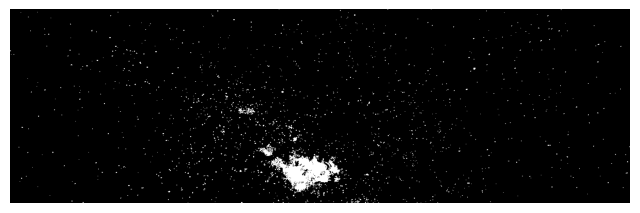

In [43]:
estrelas = ceu > 120

plt.imshow(estrelas, cmap='gray')
plt.axis('off')
plt.show()

A matriz booleana é uma imagem binária: estrelas e núcleo da Via Láctea de um lado, fundo de céu do outro. E a fração de pixels acima do limiar é um número que sabemos calcular:

In [44]:
estrelas.mean()

np.float64(0.0192109375)

Cerca de 2% do céu. Contar a fração de elementos que satisfaz uma condição foi exatamente o que fizemos para estimar $\pi$: os mesmos fundamentos reaparecem em contextos diferentes. Na pós-graduação, essa matriz será o ponto de partida de tudo: filtros, detecção de bordas, redes neurais convolucionais.

## Recapitulando

O percurso de hoje fechou o nivelamento com a pergunta do custo computacional:

- A **notação O grande** classifica algoritmos pela ordem de crescimento: constante, logarítmica, linear, log-linear, quadrática, exponencial. Constantes não importam; a classe importa.
- O **problema da Mochila** expôs o dilema central da otimização: a força bruta garante o ótimo a custo $O(n \cdot 2^n)$; o guloso entrega uma aproximação por $O(n \log n)$.
- **Monte Carlo** usa aleatoriedade para estimar quantidades determinísticas, com precisão que cresce com o número de amostras. Validade estatística não é correção.
- Uma **imagem é um array**: indexação, slicing e comparações booleanas são as primeiras ferramentas da Visão Computacional.

Em quatro aulas, saímos do zero e chegamos a algoritmos, classes, simulações e à porta de entrada da Visão Computacional. Para quem quiser aprofundar os temas de hoje, os capítulos 11, 14 e 18 do Guttag são a referência direta.

As aulas regulares da pós-graduação começam em **10 de junho**. Nos vemos lá.